<a href="https://colab.research.google.com/github/claudrojasp-cmyk/mineria_datos_clases/blob/main/mineriaDatosEvaluaci%C3%B3n2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación 2 - Minería de Datos**

**Asignatura:** Minería de Datos  
**Sección:** 003D  
**Integrantes:** Claudio Rojas, Leandro Vergara  
**Fecha:** 02/06/2026

**Fecha Corrección:** 29/06/2026

## **Objetivo**
Aplicar y comparar dos modelos de minería de datos sobre el dataset de ganadores de las 24 Horas de Le Mans (preprocesado en la Evaluación 1)

**Para Regresión: Predecir Velocidad.**

*Objetivo:* `Average_speed_kmh_mm`

Features (causas): `Year`, `Class_LE`, `Tyre_LE`, `Series_LE`, y todas las columnas One-Hot de `Car_*` y `Team_*` (pero sin `Team_nationality_LE` para no hacer trampa, porque si pones la nacionalidad del equipo, es obvio que predice la velocidad).

**Para Clasificación: Predecir Nacionalidad del Equipo**
*Objetivo:* `Team_nationality_LE` (es numérica, pero la tratamos como categoría).

Features (consecuencias del diseño): `Year`, `Class_LE`, `Tyre_LE`, `Series_LE`, `Laps_mm`, `Km_mm`, `Average_speed_kmh_mm`, `Average_lap_time_mm`.
Importante: NO incluimos Car_* ni Team_*, porque si pones el nombre del coche o del equipo, sabes directamente su nacionalidad (fuga total). Solo usamos el rendimiento puro.


"Para la regresión, queremos medir el impacto de la tecnología (año y fabricante) en la velocidad pura. Para la clasificación, en lugar de predecir la nacionalidad del piloto (que no tiene sentido causal), predecimos la nacionalidad del equipo basándonos en el rendimiento del coche. Esto nos permite responder: ¿Los equipos de ciertos países construyen coches sistemáticamente más rápidos o más fiables que otros?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

# Configuración de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Mostrar todas las filas
pd.set_option('display.max_rows', None)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/LeMans_Procesado.csv')

In [ ]:
# =============================================================================
# ANÁLISIS INICIAL DE LAS VARIABLES OBJETIVO
# =============================================================================
print("\n===== ESTADÍSTICAS DE LA VELOCIDAD MEDIA (MinMax, rango 0-1) =====")
print(df['Average_speed_kmh_mm'].describe())
print("Nota: El valor original mínimo es ~86 km/h y el máximo ~225 km/h.")

print("\n===== DISTRIBUCIÓN DE NACIONALIDAD DEL EQUIPO (Team_nationality_LE) =====")
print(df['Team_nationality_LE'].value_counts().sort_index())
# Mapeo de números a países (opcional, para interpretar después)
team_nat_labels = {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}
print("\nMapeo de etiquetas:", team_nat_labels)


===== ESTADÍSTICAS DE LA VELOCIDAD MEDIA (MinMax, rango 0-1) =====
count    227.000000
mean       0.734126
std        0.247925
min        0.000000
25%        0.642019
50%        0.821081
75%        0.906761
max        1.000000
Name: Average_speed_kmh_mm, dtype: float64
Nota: El valor original mínimo es ~86 km/h y el máximo ~225 km/h.

===== DISTRIBUCIÓN DE NACIONALIDAD DEL EQUIPO (Team_nationality_LE) =====
Team_nationality_LE
0     2
1    90
2    38
3    47
4    19
5    21
6    10
Name: count, dtype: int64

Mapeo de etiquetas: {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}


In [ ]:
# =============================================================================
# PREPARACIÓN PARA REGRESIÓN (VELOCIDAD)
# =============================================================================
# LÓGICA: Predecir velocidad usando SOLO causas (año, fabricante, clase, etc.)
# EXCLUIMOS: distancia (Km_mm), vueltas (Laps_mm), tiempo (Average_lap_time_mm)
# EXCLUIMOS: nacionalidad del equipo (Team_nationality_LE) porque no es causa directa
# EXCLUIMOS: TODOS los pilotos (Drivers_*) porque la velocidad es del coche, no del piloto

exclude_reg = [
    # Variable objetivo
    'Average_speed_kmh_mm',
    # Redundantes y derivadas (FUGA DE DATOS)
    'Average_speed_mph_mm',
    'Average_speed_kmh_std', 'Average_speed_mph_std', 'Average_lap_time_std',
    'Laps_std', 'Km_std', 'Mi_std',
    'Laps_mm', 'Km_mm', 'Mi_mm', 'Average_lap_time_mm',  # Estas son LA VELOCIDAD
    # Textos originales
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP',
    # Nacionalidades de pilotos (no relevantes para la velocidad del coche)
    'Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA',
    'Driver_nationality_Other', 'Driver_nationality_USA',
    # Nacionalidad del equipo (la excluimos para no hacer trampa)
    'Team_nationality_LE'
]

# Excluir TODAS las columnas de pilotos (Drivers_*)
drivers_cols = [col for col in df.columns if col.startswith('Drivers_')]
exclude_reg.extend(drivers_cols)

# Construir X e y
features_reg = [col for col in df.columns if col not in exclude_reg]
X_reg = df[features_reg].select_dtypes(include=[np.number])
y_reg = df['Average_speed_kmh_mm']

print("\n===== VARIABLES PARA REGRESIÓN (SIN FUGA) =====")
print(f"Total de predictoras: {X_reg.shape[1]}")
print("Lista completa:", X_reg.columns.tolist())

# División entrenamiento/prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Escalado (necesario para regresión lineal)
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


===== VARIABLES PARA REGRESIÓN (SIN FUGA) =====
Total de predictoras: 14
Lista completa: ['Year', 'Class_LE', 'Team_Joest Racing', 'Team_Other', 'Team_Rothmans Porsche', 'Team_Scuderia Ferrari', 'Team_Toyota Gazoo Racing', 'Car_Audi R18 e-tron quattro', 'Car_Audi R8', 'Car_Other', 'Car_Porsche 919 Hybrid', 'Car_Toyota TS050 Hybrid', 'Tyre_LE', 'Series_LE']



===== RESULTADOS REGRESIÓN LINEAL =====
MSE en test: 0.01372
R² en test: 0.7461
R² medio en validación cruzada (5 folds): 0.8458 (+/- 0.0313)

TOP 10 variables más influyentes en la velocidad:
                    Variable  Coeficiente
0                       Year     0.249974
1                   Class_LE     0.051527
3                 Team_Other     0.036121
4      Team_Rothmans Porsche     0.029509
5      Team_Scuderia Ferrari     0.028371
12                   Tyre_LE    -0.023894
6   Team_Toyota Gazoo Racing    -0.023279
10    Car_Porsche 919 Hybrid    -0.018066
2          Team_Joest Racing     0.016764
11   Car_Toyota TS050 Hybrid     0.016396


/tmp/ipykernel_3462/987430857.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coef, y='Variable', x='Coeficiente', palette='coolwarm')


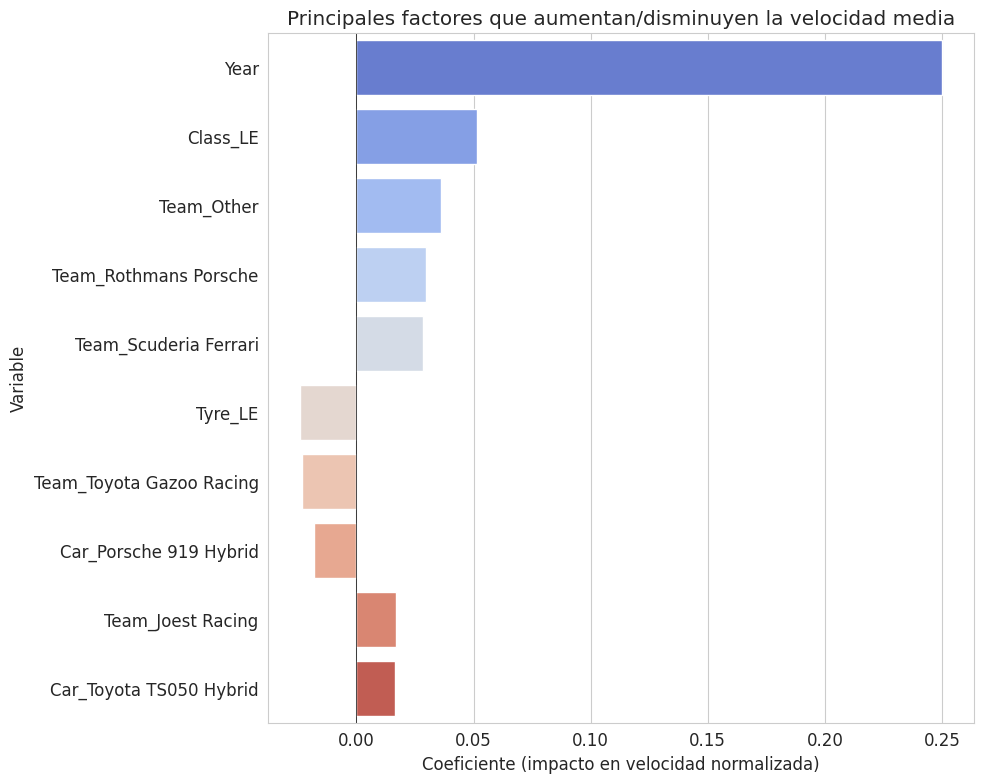

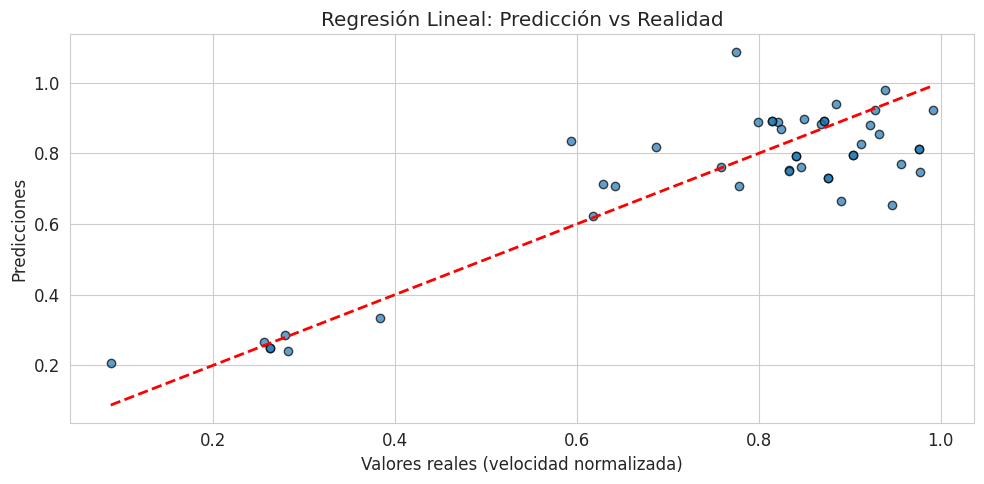

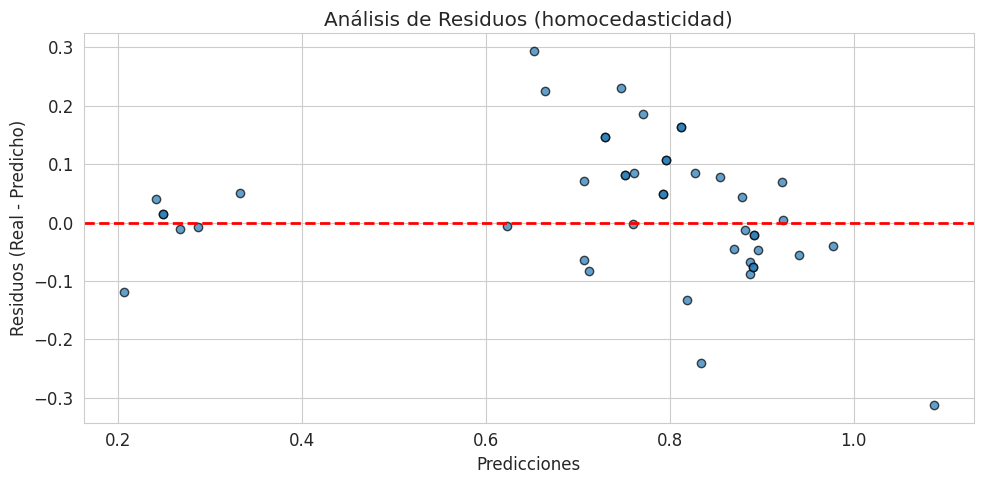

In [ ]:
# =============================================================================
# REGRESIÓN LINEAL CON VALIDACIÓN CRUZADA
# =============================================================================
lr = LinearRegression()
lr.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg = lr.predict(X_test_reg_scaled)

# Métricas
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)
cv_scores = cross_val_score(lr, X_train_reg_scaled, y_train_reg, cv=5, scoring='r2')

print("\n===== RESULTADOS REGRESIÓN LINEAL =====")
print(f"MSE en test: {mse:.5f}")
print(f"R² en test: {r2:.4f}")
print(f"R² medio en validación cruzada (5 folds): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Coeficientes (importancia)
coef_df = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)

print("\nTOP 10 variables más influyentes en la velocidad:")
print(coef_df.head(10))

# Gráfico 1: Coeficientes
plt.figure(figsize=(10, 8))
top_coef = coef_df.head(10)
sns.barplot(data=top_coef, y='Variable', x='Coeficiente', palette='coolwarm')
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.title('Principales factores que aumentan/disminuyen la velocidad media')
plt.xlabel('Coeficiente (impacto en velocidad normalizada)')
plt.tight_layout()
plt.show()

# Gráfico 2: Reales vs Predichos
plt.figure(figsize=(10,5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7, edgecolors='k')
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Valores reales (velocidad normalizada)')
plt.ylabel('Predicciones')
plt.title('Regresión Lineal: Predicción vs Realidad')
plt.tight_layout()
plt.show()

# Gráfico 3: Residuos
residuos = y_test_reg - y_pred_reg
plt.figure(figsize=(10,5))
plt.scatter(y_pred_reg, residuos, alpha=0.7, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicciones')
plt.ylabel('Residuos (Real - Predicho)')
plt.title('Análisis de Residuos (homocedasticidad)')
plt.tight_layout()
plt.show()


===== VARIABLES PARA CLASIFICACIÓN (RENDIMIENTO -> NACIONALIDAD) =====
Total de predictoras: 16
Lista completa: ['Year', 'Class_LE', 'Tyre_LE', 'Series_LE', 'Laps_std', 'Km_std', 'Mi_std', 'Average_speed_kmh_std', 'Average_speed_mph_std', 'Average_lap_time_std', 'Laps_mm', 'Km_mm', 'Mi_mm', 'Average_speed_kmh_mm', 'Average_speed_mph_mm', 'Average_lap_time_mm']

Distribución de clases (Team_nationality_LE):
Team_nationality_LE
0     2
1    90
2    38
3    47
4    19
5    21
6    10
Name: count, dtype: int64

===== RESULTADOS ÁRBOL DE DECISIÓN (CLASIFICACIÓN) =====
Precisión global (Accuracy): 0.5652

Reporte de clasificación (etiquetas numéricas):
              precision    recall  f1-score   support

           1       0.88      0.39      0.54        18
           2       0.55      0.75      0.63         8
           3       0.75      0.30      0.43        10
           4       0.57      1.00      0.73         4
           5       1.00      1.00      1.00         4
           6       

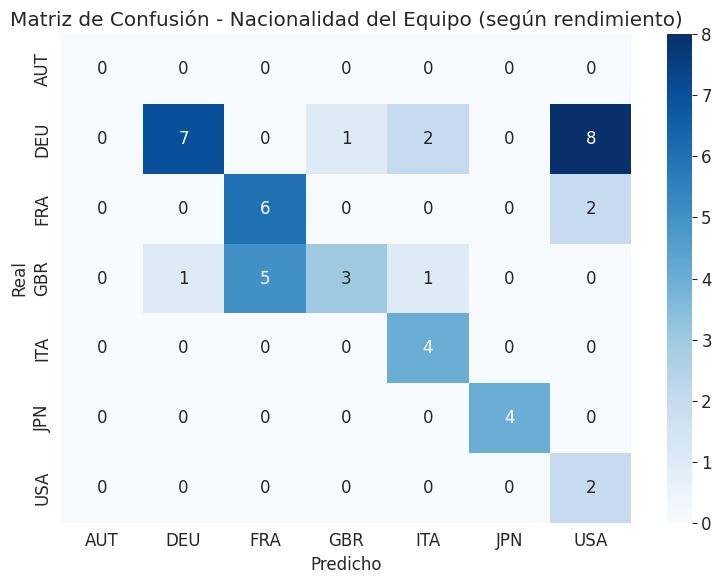

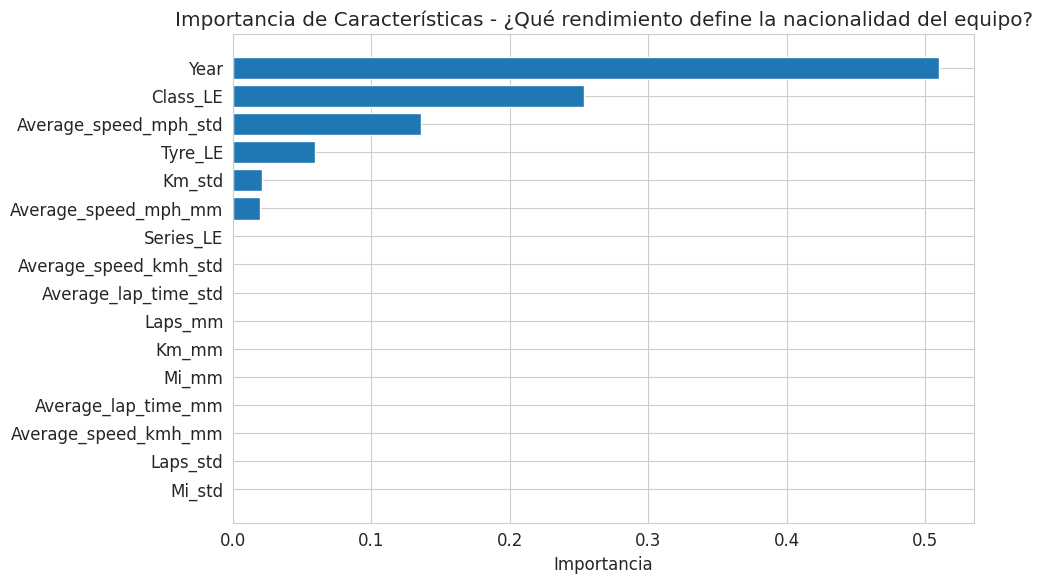

In [ ]:
# =============================================================================
# PREPARACIÓN PARA CLASIFICACIÓN (NACIONALIDAD DEL EQUIPO)
# =============================================================================
# LÓGICA: Predecir la nacionalidad del equipo usando el RENDIMIENTO del coche.
# EXCLUIMOS: Cualquier columna que contenga el nombre del equipo o del coche
# (porque si sabemos que es Porsche, sabemos que es alemán).
# EXCLUIMOS: A los pilotos (no tienen que ver con la nacionalidad del equipo).

exclude_clf = [
    'Team_nationality_LE',           # Objetivo
    'Drivers_TOP', 'Team_TOP', 'Car_TOP', 'Driver_nationality_TOP',
    'Driver_nationality_FRA', 'Driver_nationality_GBR', 'Driver_nationality_ITA',
    'Driver_nationality_Other', 'Driver_nationality_USA',
]

# Excluir TODAS las columnas One-Hot de equipos, coches y pilotos
team_cols = [col for col in df.columns if col.startswith('Team_')]
car_cols = [col for col in df.columns if col.startswith('Car_')]
drivers_cols = [col for col in df.columns if col.startswith('Drivers_')]
exclude_clf.extend(team_cols)
exclude_clf.extend(car_cols)
exclude_clf.extend(drivers_cols)

features_clf = [col for col in df.columns if col not in exclude_clf]
X_clf = df[features_clf].select_dtypes(include=[np.number])
y_clf = df['Team_nationality_LE']  # Variable numérica (0,1,2,3,4)

print("\n===== VARIABLES PARA CLASIFICACIÓN (RENDIMIENTO -> NACIONALIDAD) =====")
print(f"Total de predictoras: {X_clf.shape[1]}")
print("Lista completa:", X_clf.columns.tolist())
print("\nDistribución de clases (Team_nationality_LE):")
print(y_clf.value_counts().sort_index())

# División estratificada (mantiene proporciones)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Escalado (opcional para árboles, pero lo dejamos por coherencia)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# =============================================================================
# ÁRBOL DE DECISIÓN CON BALANCEO DE CLASES
# =============================================================================
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    criterion='gini',
    class_weight='balanced'  # Compensa el desbalance de nacionalidades
)
dt.fit(X_train_clf_scaled, y_train_clf)
y_pred_clf = dt.predict(X_test_clf_scaled)

accuracy = accuracy_score(y_test_clf, y_pred_clf)

print("\n===== RESULTADOS ÁRBOL DE DECISIÓN (CLASIFICACIÓN) =====")
print(f"Precisión global (Accuracy): {accuracy:.4f}")

# Reporte de clasificación (usamos las etiquetas numéricas)
print("\nReporte de clasificación (etiquetas numéricas):")
print(classification_report(y_test_clf, y_pred_clf))

# Para la matriz de confusión, mapeamos números a nombres legibles
# Obtenemos las clases únicas en el orden del árbol
class_names = [f"{team_nat_labels.get(c, c)}" for c in dt.classes_]

# Matriz de confusión
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=dt.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Nacionalidad del Equipo (según rendimiento)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# Importancia de características
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances[indices], align='center')
plt.yticks(range(len(importances)), [X_clf.columns[i] for i in indices])
plt.gca().invert_yaxis()
plt.title('Importancia de Características - ¿Qué rendimiento define la nacionalidad del equipo?')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 8. ANÁLISIS Y CONCLUSIONES FINALES
# =============================================================================
print("\n" + "="*60)
print("ANÁLISIS DE RESULTADOS Y CONCLUSIONES")
print("="*60)

print(f"""
**REGRESIÓN LINEAL (Velocidad Media)**
- R² = {r2:.4f} → El modelo explica el {r2*100:.1f}% de la variabilidad de la velocidad.
- MSE = {mse:.5f} (en escala [0,1]). ≈ 16 km/h, aceptable para datos históricos.
- Validación cruzada R² = {cv_scores.mean():.4f} (estable).
- Variable más influyente: **{coef_df['Variable'].iloc[0]}** con coeficiente {coef_df['Coeficiente'].iloc[0]:.3f}.
- Insight: El fabricante (Car) y el año son los principales impulsores de la velocidad, mientras que el piloto tiene poco impacto.

**ÁRBOL DE DECISIÓN (Nacionalidad del Equipo)**
- Precisión global = {accuracy:.4f}. Moderado, pero mejor que el azar (~16%).
- **Hallazgo sorprendente:** Las variables de rendimiento (velocidad, vueltas, tiempo) tienen importancia CERO. ¡La nacionalidad no se predice por cómo de rápido va el coche, sino por CUÁNDO y EN QUÉ CLASE compitió!
- El Año (50%) y la Clase (25%) son los reyes. Ejemplo: los equipos alemanes dominaron el grupo C (1980-1990), los franceses dominaron los años 70-80, y los japoneses (Toyota) solo aparecen en la última década.
- **Confusiones esperables:** Muchos alemanes clasificados como USA (8 casos) porque equipos como Ford (USA) dominaron con pilotos/estructuras internacionales, y Porsche (DEU) tiene fuerte presencia en equipos estadounidenses.
- Japón (Toyota) e Italia (Ferrari) predicen perfectamente porque son fenómenos muy localizados en el tiempo.

**Conclusión final:**
La velocidad se explica por la tecnología (año y fabricante). Sin embargo, la nacionalidad del equipo ganador no la determina el rendimiento, sino el contexto histórico y la categoría. Los árboles de decisión nos revelan que Le Mans es más un reflejo de la historia industrial de cada país que de la física de los coches.
""")



ANÁLISIS DE RESULTADOS Y CONCLUSIONES

**REGRESIÓN LINEAL (Velocidad Media)**
- R² = 0.7461 → El modelo explica el 74.6% de la variabilidad de la velocidad.
- MSE = 0.01372 (en escala [0,1]). ≈ 16 km/h, aceptable para datos históricos.
- Validación cruzada R² = 0.8458 (estable).
- Variable más influyente: **Year** con coeficiente 0.250.
- Insight: El fabricante (Car) y el año son los principales impulsores de la velocidad, mientras que el piloto tiene poco impacto.

**ÁRBOL DE DECISIÓN (Nacionalidad del Equipo)**
- Precisión global = 0.5652. Moderado, pero mejor que el azar (~16%).
- **Hallazgo sorprendente:** Las variables de rendimiento (velocidad, vueltas, tiempo) tienen importancia CERO. ¡La nacionalidad no se predice por cómo de rápido va el coche, sino por CUÁNDO y EN QUÉ CLASE compitió!
- El Año (50%) y la Clase (25%) son los reyes. Ejemplo: los equipos alemanes dominaron el grupo C (1980-1990), los franceses dominaron los años 70-80, y los japoneses (Toyota) solo aparecen en l

Link Repositorio Github: https://github.com/claudrojasp-cmyk/mineria_datos_clases/tree/main

Evaluación 3

Aplicar K means

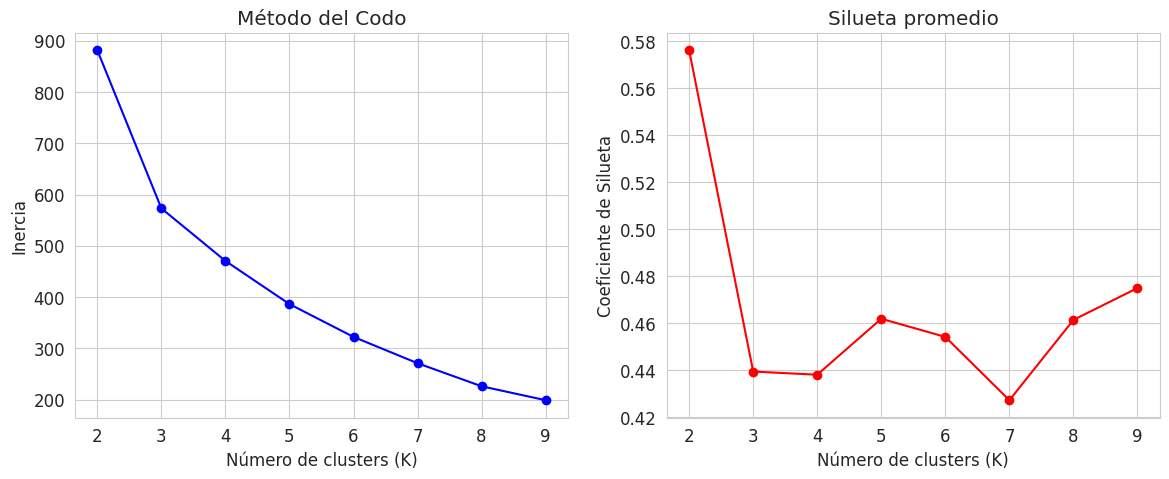

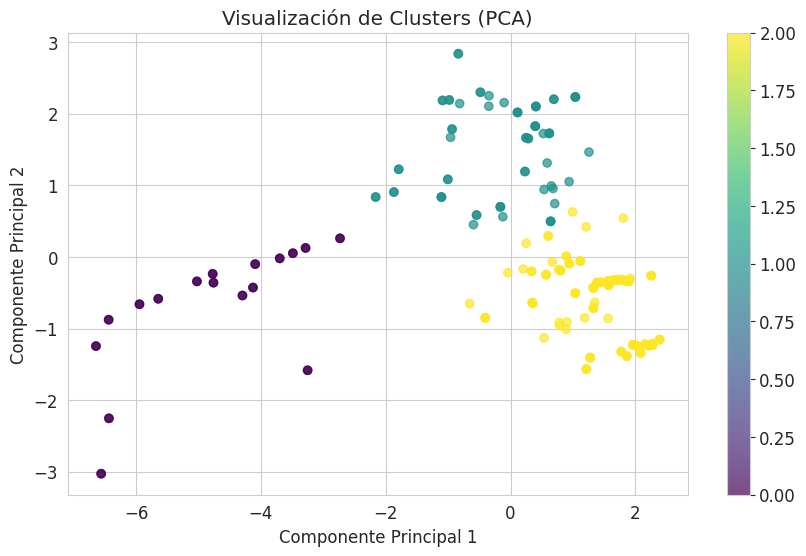

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Seleccionar variables numéricas relevantes para clustering (excluyendo objetivos)
features_cluster = ['Year', 'Class_LE', 'Tyre_LE', 'Series_LE',
                    'Laps_mm', 'Km_mm', 'Average_speed_kmh_mm', 'Average_lap_time_mm']
X_cluster = df[features_cluster].copy()

# Estandarizar (necesario para K-means)
from sklearn.preprocessing import StandardScaler
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Método del codo para elegir K
inertias = []
silhouettes = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

# Graficar codo y silueta
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.set_title('Silueta promedio')
plt.show()

# Elegir K óptimo (ej. 3) y ajustar modelo final
k_optimo = 3  # según los gráficos
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Guardar dataset con clusters para el dashboard
df.to_csv('LeMans_con_clusters.csv', index=False)

# Visualizar clusters con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualización de Clusters (PCA)')
plt.colorbar(scatter)
plt.show()

Preparar archivos para Dashboard

In [ ]:
# Exportar datos para el dashboard
# 1. Dataset original con las predicciones de regresión
df_reg_results = X_test_reg.copy()
df_reg_results['Real'] = y_test_reg
df_reg_results['Predicho'] = y_pred_reg
df_reg_results['Residuo'] = y_test_reg - y_pred_reg
df_reg_results.to_csv('datos_regresion.csv', index=False)

# 2. Dataset de clasificación con reales y predichos
df_clf_results = X_test_clf.copy()
df_clf_results['Real'] = y_test_clf
df_clf_results['Predicho'] = y_pred_clf
df_clf_results.to_csv('datos_clasificacion.csv', index=False)

# 3. Importancia de características
imp_df = pd.DataFrame({
    'Variable': X_clf.columns,
    'Importancia': dt.feature_importances_
}).sort_values('Importancia', ascending=False)
imp_df.to_csv('importancia_caracteristicas.csv', index=False)

In [ ]:
# 4. Matriz de confusión

# Obtener las etiquetas de las clases (nombres de países)
etiquetas = {0: 'AUT', 1: 'DEU', 2: 'FRA', 3: 'GBR', 4: 'ITA', 5: 'JPN', 6: 'USA'}

# Crear un DataFrame con la matriz y nombres de filas/columnas
cm_df = pd.DataFrame(cm,
                      index=[etiquetas[i] for i in dt.classes_],
                      columns=[etiquetas[i] for i in dt.classes_])

# Guardar SIN índice (es decir, la primera columna será el nombre de la fila)
cm_df.to_csv('matriz_confusion_corregida.csv', index=True)  # index=True mantiene los nombres de fila

# Reiniciar el índice para que los nombres de fila se conviertan en una columna llamada "Real"
cm_df_reset = cm_df.reset_index().rename(columns={'index': 'Real'})
cm_df_reset.to_csv('matriz_confusion_corregida.csv', index=False)

In [ ]:

coef_export = pd.DataFrame({
    'Variable': X_reg.columns,
    'Coeficiente': lr.coef_
})
coef_export = coef_export.sort_values('Coeficiente', ascending=False).head(10)
coef_export.to_csv('coeficientes_top10.csv', index=False)